In [2]:
#Import 
import gc
import faiss
import numpy as np
import pandas as pd

In [1]:
#load input
ECO         = "/projectnb/dietzelab/EricTian/Pecon_Eric_Tian/modules/assim.sequential/inst/anchor/ecoClim/ecoClim_global.csv"
OUT_DIR     = "/projectnb/dietzelab/EricTian/Pecon_Eric_Tian/modules/assim.sequential/inst/anchor/ecoClim/"
#Dongchen's version: year_since_disturb, agb, twi, tavg, srad, prec, vapr, PH, N, SOC, Sand, lat, lon
#no lat and lon, agb and SOC used in weighting, used elevation instead of twi.
#One year data used in clustering
FEAT_COLS   = ["t2m","ssrd","tp","d2m","PH","N","Sand","elevation"]
COLS        = ["LC","longitude","latitude","SOC","AGB","GEDI"]+FEAT_COLS
#no urban, snow/ice, barren, and water
SKIP_LC     = {13,15,16,17}
TOTAL_SITES = 50000 #global budget to mathch overall density of Dongchen 8000 sites in NA
DONGCHEN_NA = 8000
CLUSTER_TOTAL = 8000 #Large but Arbitrary number to make sure space filling
MIN_CLUSTERS  = 20 #Minimal clusters per LC
BASE_SITES  = 200 #Minimal sites selected per LC
BETA        = 0.5 #carbon-weighitng strength, Dr.Dietze suggests 1.5 ~ 2.0 times more likly in richest agb and SOC locations
GEDI_MULT   = 50 #GEDI density weight
NA_LON=(-179,-20); NA_LAT=(7,85) #North America range
CHUNK       = 5_000_000 #load data in chuncks to avoid memory lemit
MAKE_MAP = True
SEED = 42



In [3]:
#1. Chunked load (drop skipped LCs + NA box)
print("Chunked loading...")
dtypes = {c: "float32" for c in COLS}
buf = {c: [] for c in COLS}
total = 0
for chunk in pd.read_csv(ECO, usecols=COLS, dtype=dtypes, chunksize=CHUNK):
    total += len(chunk)
    chunk = chunk[~chunk["LC"].isin(SKIP_LC)]
    lon = chunk["longitude"].values
    lat = chunk["latitude"].values
    in_na = (lon >= NA_LON[0]) & (lon <= NA_LON[1]) & \
            (lat >= NA_LAT[0]) & (lat <= NA_LAT[1])
    chunk = chunk[~in_na]
    for c in COLS:
        buf[c].append(chunk[c].values.astype(np.float32))
    print(f"  {total:,} rows read", end="\r")
arr = {c: np.concatenate(buf[c]) for c in COLS}
del buf
gc.collect()
print(f"\nCandidate pixels (outside NA, non-skipped LC): {len(arr['LC']):,}")


Chunked loading...
  208,051,075 rows read
Candidate pixels (outside NA, non-skipped LC): 136,321,393


In [4]:
#2. Arrays + sampling weights
lc_r  = arr["LC"].astype(np.int16) #for the sake of memory
lon_r = arr["longitude"].astype(np.float64)
lat_r = arr["latitude"].astype(np.float64)
soc_r = arr["SOC"].astype(np.float64)
agb_r = arr["AGB"].astype(np.float64)
gedi_r = np.nan_to_num(arr["GEDI"], nan=0.0).astype(np.float64)
feat_r = np.column_stack([arr[c] for c in FEAT_COLS]).astype(np.float32)
del arr #for the sake of memory
gc.collect()

mu, sig = np.nanmean(feat_r, 0), np.nanstd(feat_r, 0) + 1e-12
feat_std = ((feat_r - mu) / sig).astype(np.float32) #standardize
del feat_r #for the sake of memory
gc.collect()

def norm01(x):
    lo, hi = np.nanmin(x), np.nanmax(x)
    return (x - lo) / (hi - lo + 1e-12)

area_px   = np.cos(np.abs(lat_r) * np.pi / 180)          # pixel area ~ cos(lat)
#total C weighting for soc + agb, 0 ~2
totalC    = np.nan_to_num(norm01(soc_r) + norm01(agb_r), nan=0.0)
gedi_norm = norm01(gedi_r)

In [5]:
# Within-cluster sampling weight — multiplicative latitude scaling.
w_within = area_px * (1.0 + GEDI_MULT * gedi_norm)

In [6]:
# Rationale: additive vs multiplicative weight at different latitudes.
print("Latitude-weight behaviour (pixel with gedi_norm = 1):")
for lat in [0, 30, 45, 60, 80]:
    a = np.cos(np.abs(lat) * np.pi / 180)
    add = 1 + a + GEDI_MULT * 1          # additive form
    mul = a * (1 + GEDI_MULT * 1)        # multiplicative (used here)
    print(f"  {lat:2d} deg: additive={add:.1f}  multiplicative={mul:.1f}"
          f"  |  no-GEDI: additive={1+a:.2f}  multiplicative={a:.2f}")

Latitude-weight behaviour (pixel with gedi_norm = 1):
   0 deg: additive=52.0  multiplicative=51.0  |  no-GEDI: additive=2.00  multiplicative=1.00
  30 deg: additive=51.9  multiplicative=44.2  |  no-GEDI: additive=1.87  multiplicative=0.87
  45 deg: additive=51.7  multiplicative=36.1  |  no-GEDI: additive=1.71  multiplicative=0.71
  60 deg: additive=51.5  multiplicative=25.5  |  no-GEDI: additive=1.50  multiplicative=0.50
  80 deg: additive=51.2  multiplicative=8.9  |  no-GEDI: additive=1.17  multiplicative=0.17


In [8]:
# GEDI orbital band (latitude bounds of nonzero GEDI density).
gv = gedi_r > 0
lat_n = np.nanmax(lat_r[gv]) if gv.any() else 52
lat_s = np.nanmin(lat_r[gv]) if gv.any() else -52
print(f"GEDI band: {lat_s:.0f} to {lat_n:.0f}")
#Make sure it assigened properly
def smooth_div(tot, v):
    """Largest-remainder apportionment of `tot` across weights `v`."""
    v = np.asarray(v, float)
    frac = v / v.sum()
    a = np.floor(frac * tot).astype(int)
    r = int(tot - a.sum())
    if r > 0:
        a[np.argsort(frac * tot - a)[::-1][:r]] += 1
    return a


GEDI band: -52 to 52


In [9]:
#3. Cluster & site quotas per LC
lcs = sorted(np.unique(lc_r))
n_lc = len(lcs)
area_c   = np.array([area_px[lc_r == lc].sum() for lc in lcs]) #LC weighted area
#Average Carbon per LC
carbon_c = np.array([np.average(totalC[lc_r == lc],
                                weights=area_px[lc_r == lc]) for lc in lcs])
#Least LC carbon = 0, most LC carbon = 1
carbon_norm = (carbon_c - carbon_c.min()) / \
              (carbon_c.max() - carbon_c.min() + 1e-12)
# 20 sites per LC, then assign the rest based on weighted area
k_raw = (CLUSTER_TOTAL - MIN_CLUSTERS * n_lc) * area_c / area_c.sum() \
        + MIN_CLUSTERS
k_per_lc = smooth_div(CLUSTER_TOTAL, k_raw)
print("\nClusters per LC:", {int(l): int(k) for l, k in zip(lcs, k_per_lc)},
      "total:", int(k_per_lc.sum()))

new_budget = TOTAL_SITES - DONGCHEN_NA
#Assign site based on area and carbon norm
alloc_w = area_c * (1 + BETA * carbon_norm)
#Assign at least 200 per LC, then times alloc to get how many sites per LC
s_raw = (new_budget - BASE_SITES * n_lc) * alloc_w / alloc_w.sum() + BASE_SITES
sites_per_lc = smooth_div(new_budget, s_raw)
print("Sites per LC:", {int(l): int(s) for l, s in zip(lcs, sites_per_lc)},
      "total:", int(sites_per_lc.sum()))
print(f"Carbon factor range: {(1 + BETA * carbon_norm).min():.2f}"
      f" - {(1 + BETA * carbon_norm).max():.2f}")



Clusters per LC: {1: 132, 2: 1036, 3: 64, 4: 204, 5: 348, 6: 70, 7: 983, 8: 703, 9: 1162, 10: 2189, 11: 98, 12: 882, 14: 129} total: 8000
Sites per LC: {1: 939, 2: 6784, 3: 474, 4: 1197, 5: 2206, 6: 424, 7: 4722, 8: 4053, 9: 5907, 10: 9921, 11: 636, 12: 4013, 14: 724} total: 42000
Carbon factor range: 1.00 - 1.50


In [10]:
#4. Per LC: cluster -> split quota -> stratified sampling
#Main cluster loop
rng = np.random.default_rng(SEED)
selected = []
for i, lc in enumerate(lcs):
    cls = np.where(lc_r == lc)[0] 
    k = int(k_per_lc[i])
    n_sites = int(sites_per_lc[i])
    if len(cls) == 0 or n_sites == 0:
        continue
    f = feat_std[cls]
    keep = ~np.isnan(f).any(axis=1)
    cls = cls[keep]
    f = f[keep].astype(np.float32)
    k = min(k, len(cls))
    #Train centroid to speed up when computational power is limited

    km = faiss.Kmeans(f.shape[1], k, niter=25, verbose=False, gpu=False,
                      max_points_per_centroid=256, seed=SEED)
                      #max_points_per_centroid=256 considered based on marginal improvement
                      
    km.train(f)
    _, lab = km.index.search(f, 1)
    lab = lab.flatten()
    #Every cluster in one LC get the same amount of quota
    per_cluster = smooth_div(n_sites, np.ones(k))   # equal split across clusters
    for c in range(k):
        cc = cls[lab == c]
        nc = int(per_cluster[c])
        if nc <= 0 or len(cc) == 0:
            continue
        # Stratify: inside vs outside the GEDI band, quota split by area.
        in_band = (lat_r[cc] >= lat_s) & (lat_r[cc] <= lat_n)
        band, out = cc[in_band], cc[~in_band]
        a_b, a_o = area_px[band].sum(), area_px[out].sum()
        n_b = int(round(nc * a_b / (a_b + a_o + 1e-12)))
        n_o = nc - n_b
        #make sure high lat areas are not weighted to little due to lack of GEDI
        for sub, ns in [(band, n_b), (out, n_o)]:
            if ns <= 0 or len(sub) == 0:
                continue
            ns = min(ns, len(sub))
            w = w_within[sub]
            selected.extend(rng.choice(sub, ns, replace=False,
                                       p=w / w.sum()).tolist())
    print(f"LC {int(lc)}: {len(cls):,} px, {k} clusters, {n_sites} sites  done")

selected = np.array(selected)
print(f"\nNew sites outside NA: {len(selected)}")

LC 1: 2,670,857 px, 132 clusters, 939 sites  done
LC 2: 13,697,066 px, 1036 clusters, 6784 sites  done
LC 3: 1,132,556 px, 64 clusters, 474 sites  done
LC 4: 3,075,600 px, 204 clusters, 1197 sites  done
LC 5: 7,096,153 px, 348 clusters, 2206 sites  done
LC 6: 757,126 px, 70 clusters, 424 sites  done
LC 7: 20,377,273 px, 983 clusters, 4722 sites  done
LC 8: 13,183,663 px, 703 clusters, 4053 sites  done
LC 9: 19,698,460 px, 1162 clusters, 5907 sites  done
LC 10: 36,672,695 px, 2189 clusters, 9921 sites  done
LC 11: 1,818,778 px, 98 clusters, 636 sites  done
LC 12: 14,357,397 px, 882 clusters, 4013 sites  done
LC 14: 1,769,089 px, 129 clusters, 724 sites  done

New sites outside NA: 42000


In [11]:
 #5. Output
sites = pd.DataFrame({
    "longitude": lon_r[selected], "latitude": lat_r[selected],
    "LC": lc_r[selected], "SOC": soc_r[selected],
    "AGB": agb_r[selected], "GEDI": gedi_r[selected]})
sites.to_csv(OUT_DIR + "new_sites_clustered_outside_na_latitude_weight.csv",
             index=False)
print(f"Final = {DONGCHEN_NA} NA + {len(sites)} outside NA"
      f" = {DONGCHEN_NA + len(sites)}")

Final = 8000 NA + 42000 outside NA = 50000


Map saved.


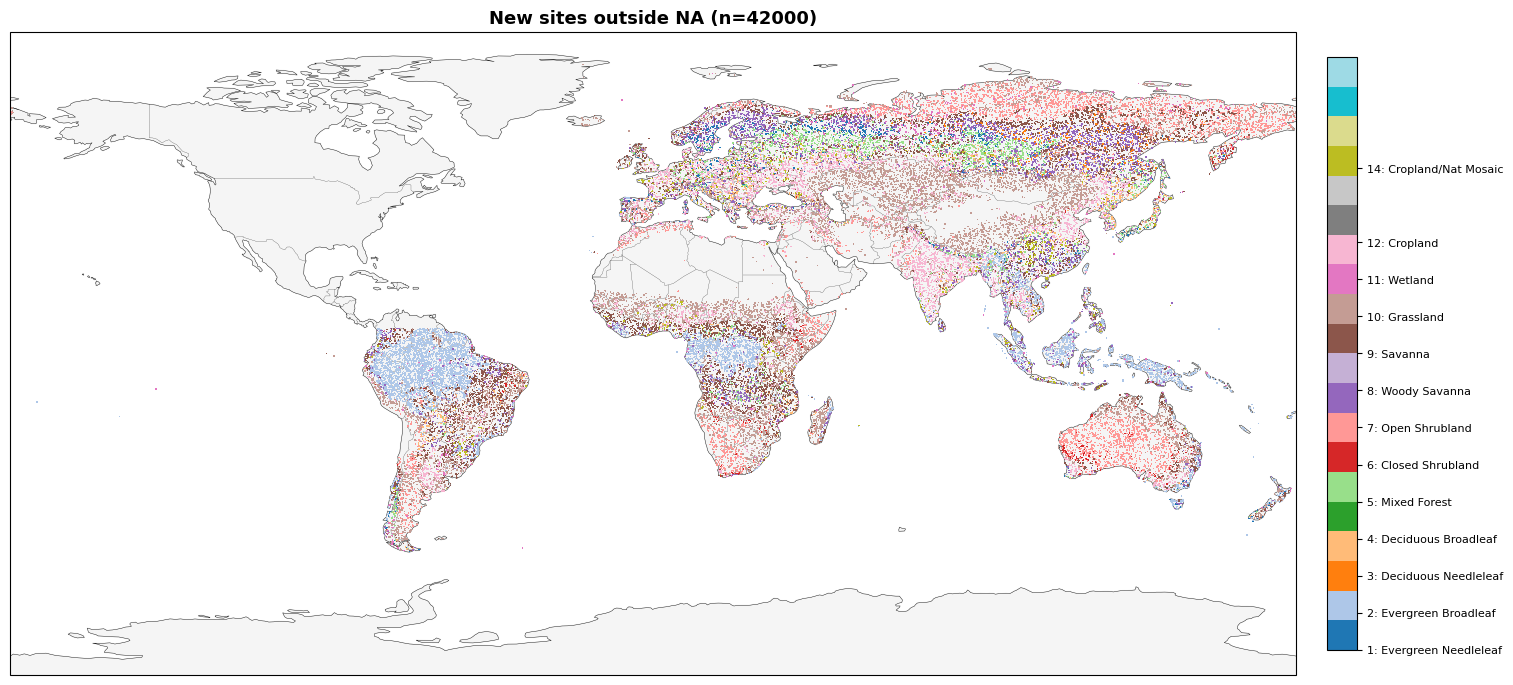

In [12]:
#6. Map (optional)
if MAKE_MAP:
    import matplotlib.pyplot as plt
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    lc_names = {1: 'Evergreen Needleleaf', 2: 'Evergreen Broadleaf',
                3: 'Deciduous Needleleaf', 4: 'Deciduous Broadleaf',
                5: 'Mixed Forest', 6: 'Closed Shrubland', 7: 'Open Shrubland',
                8: 'Woody Savanna', 9: 'Savanna', 10: 'Grassland',
                11: 'Wetland', 12: 'Cropland', 14: 'Cropland/Nat Mosaic'}
    fig, ax = plt.subplots(figsize=(20, 11),
                           subplot_kw={'projection': ccrs.PlateCarree()})
    ax.add_feature(cfeature.LAND, color='whitesmoke', zorder=0)
    ax.add_feature(cfeature.COASTLINE, lw=0.3, zorder=1)
    ax.add_feature(cfeature.BORDERS, lw=0.15, zorder=1)
    ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())
    sc = ax.scatter(sites["longitude"], sites["latitude"], c=sites["LC"],
                    cmap='tab20', vmin=1, vmax=17, s=1, marker=',',
                    linewidths=0, transform=ccrs.PlateCarree(), zorder=2)
    cbar = plt.colorbar(sc, ax=ax, shrink=0.7, pad=0.02)
    present = sorted(sites["LC"].dropna().astype(int).unique())
    cbar.set_ticks(present)
    cbar.set_ticklabels([f'{l}: {lc_names.get(l, "?")}' for l in present])
    cbar.ax.tick_params(labelsize=8)
    ax.set_title(f'New sites outside NA (n={len(sites)})',
                 fontsize=13, fontweight='bold')
    plt.savefig(OUT_DIR + 'new_sites_square_pixel_latitude.png',
                dpi=200, bbox_inches='tight')
    print("Map saved.")

In [ ]:
#interactive visual tool
#Claude Ai generated web site, drag csv and check
#singel globe:
#https://claude.ai/code/artifact/484a9307-71b4-4d2e-ae9b-64026ceabb26
#Two globes:
#https://claude.ai/artifact/BkRMUyx31DJpDzgjKegn5Q
